In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
logon=pd.read_csv("logon.csv")
file_data=pd.read_csv("file.csv")
device=pd.read_csv("device.csv")

In [2]:
logon.head()

NameError: name 'logon' is not defined

In [4]:
file_data.head()

,id,date,user,pc,filename,content
0,{L9G8-J9QE34VM-2834VDPB},01/02/2010 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1,{H0W6-L4FG38XG-9897XTEN},01/02/2010 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...
2,{M3Z0-O2KK89OX-5716MBIM},01/02/2010 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3,{E1I4-S4QS61TG-3652YHKR},01/02/2010 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4,{D4R7-E7JL45UX-0067XALT},01/02/2010 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8


In [5]:
device.head()

,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},01/02/2010 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},01/02/2010 08:04:26,IIW0249,PC-0843,Disconnect


In [6]:
logon.columns

Index(['id', 'date', 'user', 'pc', 'activity'], dtype='str')

In [7]:
logon.info()

<class 'pandas.DataFrame'>
RangeIndex: 854859 entries, 0 to 854858
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   id        854859 non-null  str  
 1   date      854859 non-null  str  
 2   user      854859 non-null  str  
 3   pc        854859 non-null  str  
 4   activity  854859 non-null  str  
dtypes: str(5)
memory usage: 32.6 MB


In [8]:
logon.describe

<bound method NDFrame.describe of                               id                 date     user       pc  \
0       {X1D9-S0ES98JV-5357PWMI}  01/02/2010 06:49:00  NGF0157  PC-6056   
1       {G2B3-L6EJ61GT-2222RKSO}  01/02/2010 06:50:00  LRR0148  PC-4275   
2       {U6Q3-U0WE70UA-3770UREL}  01/02/2010 06:53:04  LRR0148  PC-4124   
3       {I0N5-R7NA26TG-6263KNGM}  01/02/2010 07:00:00  IRM0931  PC-7188   
4       {D1S0-N6FH62BT-5398KANK}  01/02/2010 07:00:00  MOH0273  PC-6699   
...                          ...                  ...      ...      ...   
854854  {J8R2-H0FA17MQ-9304VEVQ}  05/17/2011 04:40:33  JDF0593  PC-6301   
854855  {P3L5-A2AC53JU-4012GIRD}  05/17/2011 05:21:58  MLM0950  PC-9787   
854856  {P2S0-P1JS62IF-2767BEPH}  05/17/2011 05:25:33  IRM0931  PC-7188   
854857  {Z2U6-I8MA03NC-4963HKBH}  05/17/2011 06:23:48  IRM0931  PC-7188   
854858  {T0U1-P7DT83QQ-7295ICZR}  05/17/2011 06:43:35  BJM0111  PC-6866   

       activity  
0         Logon  
1         Logon  
2         L

In [9]:
logon["date"] = pd.to_datetime(logon["date"])
device["date"] = pd.to_datetime(device["date"])
file_data["date"] = pd.to_datetime(file_data["date"])

In [10]:
logon.head()

,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},2010-01-02 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},2010-01-02 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},2010-01-02 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},2010-01-02 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},2010-01-02 07:00:00,MOH0273,PC-6699,Logon


In [11]:
logon["hour"] = logon["date"].dt.hour

In [12]:
logon.head()

,id,date,user,pc,activity,hour
0,{X1D9-S0ES98JV-5357PWMI},2010-01-02 06:49:00,NGF0157,PC-6056,Logon,6
1,{G2B3-L6EJ61GT-2222RKSO},2010-01-02 06:50:00,LRR0148,PC-4275,Logon,6
2,{U6Q3-U0WE70UA-3770UREL},2010-01-02 06:53:04,LRR0148,PC-4124,Logon,6
3,{I0N5-R7NA26TG-6263KNGM},2010-01-02 07:00:00,IRM0931,PC-7188,Logon,7
4,{D1S0-N6FH62BT-5398KANK},2010-01-02 07:00:00,MOH0273,PC-6699,Logon,7


In [13]:
logon[["date", "hour"]].head()

,date,hour
0,2010-01-02 06:49:00,6
1,2010-01-02 06:50:00,6
2,2010-01-02 06:53:04,6
3,2010-01-02 07:00:00,7
4,2010-01-02 07:00:00,7


In [14]:
late_logins = logon[
    (logon["hour"] < 6) |
    (logon["hour"] > 20)
]

In [15]:
late_logins

,id,date,user,pc,activity,hour
129,{K9L4-L1HS62OX-5868NLCT},2010-01-03 00:56:15,BSS0369,PC-8884,Logon,0
130,{Q8R9-N8BX35KN-2209CPLO},2010-01-03 01:12:00,BSS0369,PC-8884,Logoff,1
274,{P8Y4-F5GH91ZR-5479XMPU},2010-01-04 00:04:43,JGT0221,PC-3814,Logon,0
275,{Z9R4-P8VW35GF-0976DSOZ},2010-01-04 00:11:32,JGT0221,PC-3814,Logoff,0
276,{J6O3-T0RN74QK-2596VMWI},2010-01-04 00:12:17,MVH0373,PC-4176,Logon,0
...,...,...,...,...,...,...
854852,{G4Z1-T4DJ41QM-4151VRUH},2011-05-17 03:09:35,BJM0111,PC-6866,Logon,3
854853,{L7J3-B5IF36LN-3971NUOQ},2011-05-17 03:18:35,JDF0593,PC-6301,Logon,3
854854,{J8R2-H0FA17MQ-9304VEVQ},2011-05-17 04:40:33,JDF0593,PC-6301,Logoff,4
854855,{P3L5-A2AC53JU-4012GIRD},2011-05-17 05:21:58,MLM0950,PC-9787,Logoff,5


In [16]:
late_login_counts = (
    late_logins.groupby("user")
    .size()
    .reset_index(name="late_logins")
)

In [17]:
late_login_counts

,user,late_logins
0,AAM0658,233
1,ACC0042,1143
2,ACV0812,101
3,AGB0643,346
4,AHG0634,162
...,...,...
189,WPR0368,1400
190,WXH0872,31
191,XRS0633,346
192,YWW0660,261


In [18]:
usb_counts = (
    device.groupby("user")
    .size()
    .reset_index(name="usb_events")
)

In [19]:
usb_counts

,user,usb_events
0,AAF0535,688
1,AAM0658,13
2,ABC0174,1276
3,AHD0848,299
4,AHM0410,782
...,...,...
260,WXH0872,1403
261,XAA0104,274
262,XHW0498,846
263,XWD0923,1047


In [20]:
file_counts = (
    file_data.groupby("user")
    .size()
    .reset_index(name="file_accesses")
)

In [21]:
file_counts

,user,file_accesses
0,AAF0535,357
1,AAM0658,31
2,ABC0174,589
3,AHD0848,199
4,AHM0410,2198
...,...,...
259,WXH0872,826
260,XAA0104,437
261,XHW0498,386
262,XWD0923,5915


In [22]:
features = late_login_counts.merge(
    usb_counts,
    on="user",
    how="outer"
)

features = features.merge(
    file_counts,
    on="user",
    how="outer"
)

In [23]:
features

,user,late_logins,usb_events,file_accesses
0,AAF0535,NaN,688.0,357.0
1,AAM0658,233.0,13.0,31.0
2,ABC0174,NaN,1276.0,589.0
3,ACC0042,1143.0,NaN,NaN
4,ACV0812,101.0,NaN,NaN
...,...,...,...,...
353,XRS0633,346.0,NaN,NaN
354,XWD0923,NaN,1047.0,5915.0
355,YWW0660,261.0,NaN,NaN
356,ZKS0899,NaN,5968.0,8537.0


In [24]:
features = features.fillna(0)

In [25]:
features

,user,late_logins,usb_events,file_accesses
0,AAF0535,0.0,688.0,357.0
1,AAM0658,233.0,13.0,31.0
2,ABC0174,0.0,1276.0,589.0
3,ACC0042,1143.0,0.0,0.0
4,ACV0812,101.0,0.0,0.0
...,...,...,...,...
353,XRS0633,346.0,0.0,0.0
354,XWD0923,0.0,1047.0,5915.0
355,YWW0660,261.0,0.0,0.0
356,ZKS0899,0.0,5968.0,8537.0


In [26]:
features["threat"] = (
    (features["late_logins"] > 10) |
    (features["usb_events"] > 50) |
    (features["file_accesses"] > 200)
).astype(int)

In [27]:
features

,user,late_logins,usb_events,file_accesses,threat
0,AAF0535,0.0,688.0,357.0,1
1,AAM0658,233.0,13.0,31.0,1
2,ABC0174,0.0,1276.0,589.0,1
3,ACC0042,1143.0,0.0,0.0,1
4,ACV0812,101.0,0.0,0.0,1
...,...,...,...,...,...
353,XRS0633,346.0,0.0,0.0,1
354,XWD0923,0.0,1047.0,5915.0,1
355,YWW0660,261.0,0.0,0.0,1
356,ZKS0899,0.0,5968.0,8537.0,1


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [29]:
X = features.drop(["user", "threat"], axis=1)
y = features["threat"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
predictions = model.predict(X_test)

In [33]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.98      0.99        65

    accuracy                           0.99        72
   macro avg       0.94      0.99      0.96        72
weighted avg       0.99      0.99      0.99        72



In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[ 7  0]
 [ 1 64]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.98      0.99        65

    accuracy                           0.99        72
   macro avg       0.94      0.99      0.96        72
weighted avg       0.99      0.99      0.99        72



In [35]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance)



         Feature  Importance
0    late_logins    0.487033
2  file_accesses    0.260334
1     usb_events    0.252633


In [37]:
features["risk_score"] = (
    features["late_logins"] * 2 +
    features["file_accesses"] * 1.5 +
    features["usb_events"] * 0.5
)

In [38]:
def risk_level(score):
    if score > 200:
        return "HIGH"
    elif score > 100:
        return "MEDIUM"
    else:
        return "LOW"

features["risk_level"] = features["risk_score"].apply(risk_level)

In [39]:
features.sort_values(
    by="risk_score",
    ascending=False
).head(10)

,user,late_logins,usb_events,file_accesses,threat,risk_score,risk_level
13,AJF0370,1250.0,8502.0,11053.0,1,23330.5,HIGH
151,HSB0196,26.0,7595.0,11627.0,1,21290.0,HIGH
220,LBH0942,0.0,7785.0,10889.0,1,20226.0,HIGH
95,DLM0051,0.0,7533.0,10673.0,1,19776.0,HIGH
147,HPH0075,0.0,6345.0,9323.0,1,17157.0,HIGH
245,MOH0273,0.0,6295.0,9306.0,1,17106.5,HIGH
356,ZKS0899,0.0,5968.0,8537.0,1,15789.5,HIGH
86,DBB0384,0.0,5932.0,8543.0,1,15780.5,HIGH
304,SAA0999,0.0,5971.0,8468.0,1,15687.5,HIGH
284,QRM0739,0.0,5962.0,8401.0,1,15582.5,HIGH


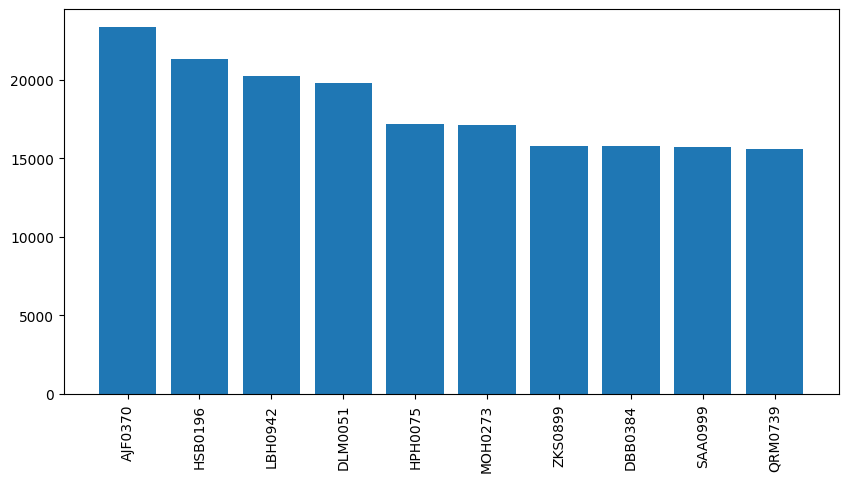

In [40]:
import matplotlib.pyplot as plt

top_users = features.sort_values(
    by="risk_score",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_users["user"], top_users["risk_score"])
plt.xticks(rotation=90)
plt.show()

In [41]:
import pickle

with open("insider_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [42]:
features.head()

,user,late_logins,usb_events,file_accesses,threat,risk_score,risk_level
0,AAF0535,0.0,688.0,357.0,1,879.5,HIGH
1,AAM0658,233.0,13.0,31.0,1,519.0,HIGH
2,ABC0174,0.0,1276.0,589.0,1,1521.5,HIGH
3,ACC0042,1143.0,0.0,0.0,1,2286.0,HIGH
4,ACV0812,101.0,0.0,0.0,1,202.0,HIGH


In [43]:
features.shape

(358, 7)

In [44]:
features.describe()

,late_logins,usb_events,file_accesses,threat,risk_score
count,358.000000,358.000000,358.000000,358.000000,358.000000
mean,159.522346,1132.346369,1244.639665,0.913408,2752.177374
std,322.874759,1854.454139,2232.363943,0.281630,4077.579247
min,0.000000,0.000000,0.000000,0.000000,10.000000
25%,0.000000,0.000000,0.000000,1.000000,562.375000
50%,6.000000,327.500000,404.000000,1.000000,1261.000000
75%,104.750000,1316.500000,1387.750000,1.000000,3157.000000
max,1400.000000,8502.000000,11627.000000,1.000000,23330.500000


In [45]:
logon["activity"].value_counts()

activity
Logon     470591
Logoff    384268
Name: count, dtype: int64

In [46]:
logon_only = logon[logon["activity"] == "Logon"]

In [47]:
late_logins = logon_only[
    (logon_only["hour"] < 6) |
    (logon_only["hour"] > 20)
]

In [48]:
late_login_counts = (
    late_logins
    .groupby("user")
    .size()
    .reset_index(name="late_logins")
)

In [49]:
device["activity"].value_counts()

activity
Connect       203339
Disconnect    202041
Name: count, dtype: int64

In [50]:
usb_connects = device[
    device["activity"] == "Connect"
]

In [51]:
usb_counts = (
    usb_connects
    .groupby("user")
    .size()
    .reset_index(name="usb_events")
)

In [54]:
file_data.columns

Index(['id', 'date', 'user', 'pc', 'filename', 'content'], dtype='str')

In [55]:
file_counts = (
    file_data.groupby("user")
    .size()
    .reset_index(name="file_accesses")
)

In [56]:
file_data["filename"].head()

0    EYPC9Y08.doc
1    N3LTSU3O.pdf
2    D3D3WC9W.doc
3    QCSW62YS.doc
4    AU75JV6U.jpg
Name: filename, dtype: str

In [57]:
file_counts

,user,file_accesses
0,AAF0535,357
1,AAM0658,31
2,ABC0174,589
3,AHD0848,199
4,AHM0410,2198
...,...,...
259,WXH0872,826
260,XAA0104,437
261,XHW0498,386
262,XWD0923,5915


In [59]:
file_data["extension"] = (
    file_data["filename"]
    .str.split(".")
    .str[-1]
)

In [60]:
file_data["extension"].value_counts().head(20)

extension
doc    285897
pdf     87953
txt     23033
jpg     22895
zip     22829
exe      2974
Name: count, dtype: int64

In [61]:
from sklearn.ensemble import IsolationForest

In [62]:
file_data.head()

,id,date,user,pc,filename,content,extension
0,{L9G8-J9QE34VM-2834VDPB},2010-01-02 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...,doc
1,{H0W6-L4FG38XG-9897XTEN},2010-01-02 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...,pdf
2,{M3Z0-O2KK89OX-5716MBIM},2010-01-02 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...,doc
3,{E1I4-S4QS61TG-3652YHKR},2010-01-02 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...,doc
4,{D4R7-E7JL45UX-0067XALT},2010-01-02 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8,jpg


In [63]:
file_data["filename"].head(20)

0     EYPC9Y08.doc
1     N3LTSU3O.pdf
2     D3D3WC9W.doc
3     QCSW62YS.doc
4     AU75JV6U.jpg
5     8ICKVGMO.doc
6     BAO9D5H2.doc
7     1PO60RXU.doc
8     JS09VZOJ.doc
9     MJVNF4DQ.doc
10    LX0I6B1U.pdf
11    WX1IWCEK.txt
12    DPKEXX7J.txt
13    IDJDLCL3.pdf
14    BCG1T122.doc
15    THZZWCOX.doc
16    3QKY90BK.txt
17    EKF5WGJ8.doc
18    STZG8JBH.pdf
19    VX3DF6HY.doc
Name: filename, dtype: str

In [64]:
file_data["content"].head(20)

0     D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1     25-50-44-46-2D carpenters 25 landed strait dis...
2     D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3     D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4                                                 FF-D8
5     D0-CF-11-E0-A1-B1-1A-E1 county one able 1367 h...
6     D0-CF-11-E0-A1-B1-1A-E1 special decided barrag...
7     D0-CF-11-E0-A1-B1-1A-E1 major became many 2010...
8     D0-CF-11-E0-A1-B1-1A-E1 yet chamberlain own co...
9     D0-CF-11-E0-A1-B1-1A-E1 identify 1942 communic...
10    25-50-44-46-2D found british conflict close th...
11    5A-55-4B-41 patients addresses evacuated 5000 ...
12    46-34-56-57 ships approach march well 1990 arr...
13    25-50-44-46-2D 3000 wardeux piece apparent cov...
14    D0-CF-11-E0-A1-B1-1A-E1 securing brigade hbos ...
15    D0-CF-11-E0-A1-B1-1A-E1 lands effectively just...
16    44-33-49-35 though answered morning up worse s...
17    D0-CF-11-E0-A1-B1-1A-E1 protect accidents 

In [ ]:
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

In [66]:
features.to_csv("features.csv", index=False)

In [1]:
import os

print(os.getcwd())

C:\Users\abcd


In [2]:
import os

print(os.listdir())

['.antigravity', '.copilot', '.gemini', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.node_repl_history', '.streamlit', '.VirtualBox', '.vscode', '.vscode-shared', '3D Objects', 'app.py', 'AppData', 'Application Data', 'archive (2).zip', 'bargraph.pdf', 'bargraph.png', 'Contacts', 'Cookies', 'CrossDevice', 'device.csv', 'Documents', 'Downloads', 'family.csv', 'familys.csv', 'Favorites', 'features.csv', 'file.csv', 'insider_model.pkl', 'insurance.csv', 'Links', 'Local Settings', 'logon.csv', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{e3b2c62d-fc39-11ef-9aec-ccd332b5a051}.TxR.0.regtrans-ms', 'NTUSER.DAT{e3b2c62d-fc39-11ef-9aec-ccd332b5a051}.TxR.1.regtrans-ms', 'NTUSER.DAT{e3b2c62d-fc39-11ef-9aec-ccd332b5a051}.TxR.2.regtrans-ms', 'NTUSER.DAT{e3b2c62d-fc39-11ef-9aec-ccd332b5a051}.TxR.blf', 'NTUSER.DAT{e3b2c62e-fc39-11ef-9aec-ccd332b5a051}.TM.blf', 'NTUSER.DAT{e3b2c62e-fc39-11ef-9aec-ccd332b5a0